**Task 1: Find the Largest and Smallest Without Using max() or min()**

Random Generated Scores:
[77 95 26 20 79 82 51 14 83 51 15 13 41 68 40 84  0 42 52 95 23 82  7 33
 74 57 93 75 91 82]

Stats using built in functions: 
Average Score:  54.833333333333336
Median Score:  54.5
Max Score:  95
Min Score:  0

Min Max Values through custom minmax function: 
MAX : 95
MIN : 0
   score  aboveMean
0     77       True
1     95       True
2     26      False
3     20      False
4     79       True
5     82       True
6     51      False
7     14      False
8     83       True
9     51      False 

           score
count  30.000000
mean   54.833333
std    30.128556
min     0.000000
25%    27.750000
50%    54.500000
75%    82.000000
max    95.000000 



<function matplotlib.pyplot.show(close=None, block=None)>

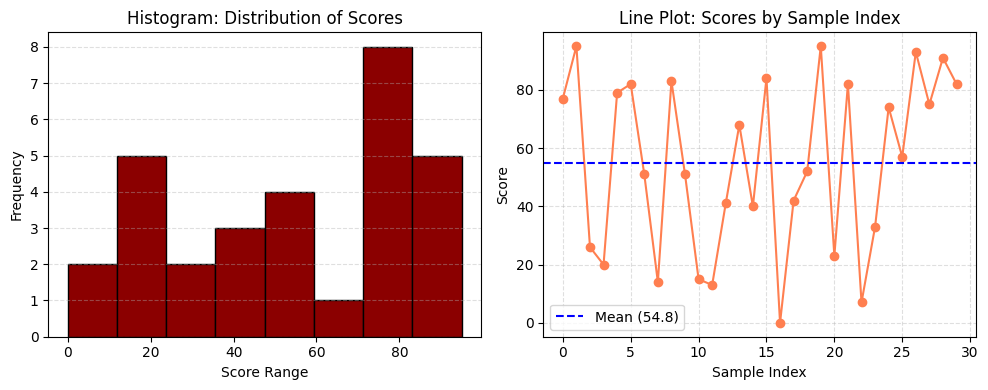

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)
scores = rng.integers(0, 100, size = 30)
print("Random Generated Scores:")
print(scores)
print("\nStats using built in functions: ")
print("Average Score: ", np.mean(scores))
print("Median Score: ", np.median(scores))
print("Max Score: ", np.max(scores))
print("Min Score: ", np.min(scores))

def minmax(scores):
  min = max = scores[0]
  for s in scores:
    if s > max:
      max = s
    elif s < min:
      min = s
  print("MAX :", max)
  print("MIN :", min)
print("\nMin Max Values through custom minmax function: ")
minmax(scores)

df = pd.DataFrame({"score" : scores})
df["aboveMean"] = df["score"] > df["score"].mean()
print(df.head(10), "\n")
print(df.describe(),"\n")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["score"], bins=8, color="darkred", edgecolor="black")
plt.title("Histogram: Distribution of Scores")
plt.xlabel("Score Range")
plt.ylabel("Frequency")
plt.grid(axis ="y", linestyle ="--", alpha=0.4)

plt.subplot(1,2,2)
plt.plot(df.index, df["score"], marker="o", color="coral", linestyle="-")
plt.axhline(df["score"].mean(), color="blue", linestyle="--", label=f'Mean ({df["score"].mean():.1f})')
plt.title("Line Plot: Scores by Sample Index")
plt.xlabel("Sample Index")
plt.ylabel("Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show

**Task 2: Build a Student Spreadsheet with a Calculated Column**

In [ ]:
students_df = pd.DataFrame({
    "student" : ["Ali", "Ahmed", "Suleman", "Haris", "Asifa"],
    "quiz" : [10,8,7,6,5],
    "midterm" : [30,28,26,24,22],
    "final" : [60,55,50,45,40]
})
students_df["total"] = students_df["quiz"] + students_df["midterm"] + students_df["final"]
print(students_df[['student', 'total']])

   student  total
0      Ali    100
1    Ahmed     91
2  Suleman     83
3    Haris     75
4    Asifa     67


**Task 3: Compare Mean vs. Median on 100 Random Values**

*---The mean is the sum divided by total count (easily skewed by one super-high score). The median is the exact number sitting in the physical middle when sorted*

Mean:  46.27
Median:  41.0 



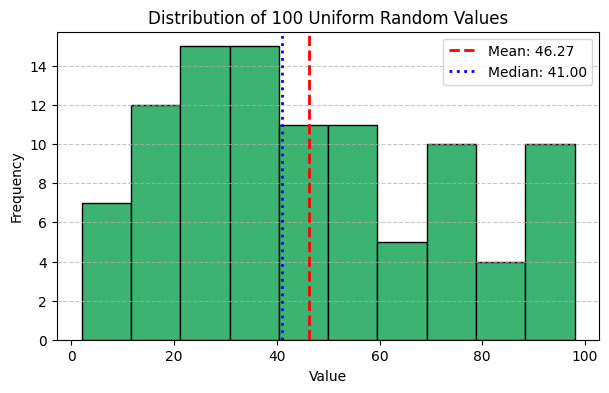

In [ ]:
vals = rng.integers(1,100, size = 100)
print("Mean: ", np.mean(vals))
print("Median: ", np.median(vals),"\n")

plt.figure(figsize=(7, 4))
plt.hist(vals, bins=10, color="mediumseagreen", edgecolor="black")
plt.axvline(
    np.mean(vals), color="red", linestyle="--", linewidth=2, label=f"Mean: {np.mean(vals):.2f}"
)
plt.axvline(
    np.median(vals),
    color="blue",
    linestyle=":",
    linewidth=2,
    label=f"Median: {np.median(vals):.2f}",
)
plt.title("Distribution of 100 Uniform Random Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**Task 4: Filter Rows with Two Conditions**

In [ ]:
topStudents = students_df[(students_df["total"] >= 80) & (students_df["quiz"] >= 8)]
print("Number of Top Students: ", len(topStudents))

Number of Top Students:  2


**Task 5: Normalization (Z-Score) Formula**

---If one test is out of 20 and another is out of 1000, AI algorithms get confused by the big numbers. Z-score converts all numbers to a scale centered at 0:

In [ ]:
val = students_df["total"]
students_df["zScore"] = (val - val.mean())/ val.std()
print(students_df["zScore"])

0    1.295377
1    0.601425
2   -0.015421
3   -0.632267
4   -1.249114
Name: zScore, dtype: float64
